In [1]:
import pandas as pd # Untuk membaca dan mengolah data berbentuk tabel (DataFrame)
import numpy as np # Operasi Matematika dan Komputasi Angka
import os # Untuk manajemen direktori/folder
from sklearn.preprocessing import MinMaxScaler # Skalasi Data (Normalisasi)

# Fungsi membersihkan mata uang di dataset (menghapus titik, ubah koma ke titik)
def clean_currency(x):
    if isinstance(x, str):
        return x.replace('.', '').replace(',', '.')
    return x

# Path dataset (Silakan sesuaikan base_path ini dengan direktori komputer Anda)
base_path = r'C:\Users\evald\OneDrive\Documents\Skripsi\Dataset'

file_names = [
    "Data Historis KLBF.csv",
    "Data Historis PEHA.csv",
    "Data Historis SIDO.csv",
    "Data Historis SOHO.csv"
]

# Dictionary untuk memetakan singkatan kode saham ke nama perusahaan lengkap sesuai dataset
stock_mapping = {
    "KLBF": "Kalbe Farma Tbk PT (KLBF)",
    "PEHA": "Phapros Tbk PT (PEHA)",
    "SIDO": "Sido Muncul Tbk PT (SIDO)",
    "SOHO": "Soho Global Health Tbk Pt (SOHO)"
}

processed_dfs = {}

print("="*60)
print("📥 MENAMPILKAN DATASET SEBELUM PREPROCESSING")
print("="*60)

for file in file_names:
    full_path = os.path.join(base_path, file)
    
    if not os.path.exists(full_path):
        print(f"⚠️ File TIDAK ditemukan: {full_path}")
        continue

    # Membaca Data Mentah dengan separator ';' sesuai format file .csv Anda
    df_raw = pd.read_csv(full_path, sep=';')

    print(f"\n📊 Dataset RAW: {file}")
    print(f"Shape Awal: {df_raw.shape}")
    
    # Pemrosesan Data
    df = df_raw.copy()

    # Membersihkan nama kolom (menghapus spasi atau karakter aneh BOM)
    df.columns = [c.replace('\ufeff', '').strip() for c in df.columns]
    
    # Bersihkan nilai string mata uang dan ubah tipe datanya menjadi float
    df['Terakhir'] = df['Terakhir'].apply(clean_currency).astype(float)
    
    # Format Kolom Tanggal agar dikenali sebagai objek datetime
    df['Tanggal'] = pd.to_datetime(df['Tanggal'], dayfirst=True)
    
    # Urutkan data berdasarkan tanggal dari masa lampau hingga yang paling baru (Wajib untuk Time Series)
    df = df.sort_values('Tanggal').reset_index(drop=True)
    
    # === TAMBAHAN: HITUNG LOG RETURN ===
    # Rumus: ln(Harga_Hari_Ini / Harga_Kemarin)
    df['Log_Return'] = np.log(df['Terakhir'] / df['Terakhir'].shift(1))
    
    # Drop baris pertama karena menghasilkan nilai NaN akibat tidak punya data hari sebelumnya
    df = df.dropna(subset=['Log_Return']).reset_index(drop=True)
    
    # === PENYESUAIAN UNIVARIATE: Menggunakan fitur 'Log_Return' sebagai input ===
    feature_cols = ['Log_Return']
    
    # Mengambil nilai array dari kolom 'Log_Return' dan dibentuk menjadi matriks 2D [Jumlah_Baris, 1]
    features = df[feature_cols].values 
    
    # Lakukan fit dan transform menggunakan MinMaxScaler khusus untuk Log Return per emiten
    scaler = MinMaxScaler()
    scaled_features = scaler.fit_transform(features)
    
    # Mengambil inisial (KLBF, PEHA, SIDO, SOHO) dari nama file asli
    stock_code = file.replace('Data Historis ', '').replace('.csv', '')
    
    # Mengubah nama stock berdasarkan nama lengkap perusahaan sesuai mapping dictionary
    full_stock_name = stock_mapping.get(stock_code, stock_code)
    
    # Menyimpan hasil akhir ke dalam dictionary processed_dfs
    processed_dfs[full_stock_name] = {
        # Menyimpan kolom Tanggal, Terakhir (Asli), dan Log_Return
        'df': df[['Tanggal', 'Terakhir', 'Log_Return']].reset_index(drop=True), 
        'scaled': scaled_features,                                  # Matriks normalisasi Log Return berdimensi [N, 1]
        'scaler': scaler                                            # Objek scaler disimpan untuk proses denormalisasi nanti
    }
    
    print(f"Shape Setelah Log Return & Drop NaN: {df.shape}")
    print(f"✅ Preprocessing {full_stock_name} selesai.")
    print("-"*50)

# Hasil Setelah Preprocessing Univariate Log Return
print("\n" + "="*60)
print("📊 HASIL SETELAH PREPROCESSING (1 INPUT: UNIVARIATE 'LOG_RETURN')")
print("="*60)

for stock, content in processed_dfs.items():
    print(f"\n📈 Dataset: {stock}")
    print(f"Shape Target Scaled: {content['scaled'].shape}") # Akan menghasilkan (jumlah_baris, 1)
    
    # Menampilkan Hasil DataFrame bersih teratas (Terlihat kolom Log_Return sudah terisi)
    print(content['df'].head(5))

📥 MENAMPILKAN DATASET SEBELUM PREPROCESSING

📊 Dataset RAW: Data Historis KLBF.csv
Shape Awal: (738, 7)
Shape Setelah Log Return & Drop NaN: (737, 8)
✅ Preprocessing Kalbe Farma Tbk PT (KLBF) selesai.
--------------------------------------------------

📊 Dataset RAW: Data Historis PEHA.csv
Shape Awal: (738, 7)
Shape Setelah Log Return & Drop NaN: (737, 8)
✅ Preprocessing Phapros Tbk PT (PEHA) selesai.
--------------------------------------------------

📊 Dataset RAW: Data Historis SIDO.csv
Shape Awal: (738, 7)
Shape Setelah Log Return & Drop NaN: (737, 8)
✅ Preprocessing Sido Muncul Tbk PT (SIDO) selesai.
--------------------------------------------------

📊 Dataset RAW: Data Historis SOHO.csv
Shape Awal: (651, 7)
Shape Setelah Log Return & Drop NaN: (650, 8)
✅ Preprocessing Soho Global Health Tbk Pt (SOHO) selesai.
--------------------------------------------------

📊 HASIL SETELAH PREPROCESSING (1 INPUT: UNIVARIATE 'LOG_RETURN')

📈 Dataset: Kalbe Farma Tbk PT (KLBF)
Shape Target Scal


DATA SPLIT (UNIVARIATE LOG RETURN)
Train : (559, 30, 1)
Test  : (142, 30, 1)

RENTANG TANGGAL DATASET
Data Latih (Train) : 03 January 2023 s/d 07 July 2025
Data Uji (Test)    : 08 July 2025 s/d 09 February 2026

SUMMARY MODEL Kalbe Farma Tbk PT (KLBF)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer_2               │ (None, 32)             │            62 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,645 (18.14 KB)

 Trainable params: 4,645 (18.14 KB)

 Non-trainable params: 0 (0.00 B)


Training model Kalbe Farma Tbk PT (KLBF) dengan Huber Loss...
Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0811 - mae: 0.3824 - val_loss: 0.0685 - val_mae: 0.3176
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0283 - mae: 0.1947 - val_loss: 0.0285 - val_mae: 0.1932
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0090 - mae: 0.1040 - val_loss: 0.0199 - val_mae: 0.1612
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0064 - mae: 0.0864 - val_loss: 0.0188 - val_mae: 0.1581
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0059 - mae: 0.0819 - val_loss: 0.0188 - val_mae: 0.1573
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0057 - mae: 0.0810 - val_loss: 0.0186 - val_mae: 0.1571
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0057 - mae: 0.0809 - val_loss: 0.0186 - val_mae: 0.1571
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0057 - mae: 0.0808 - val_loss: 0.0186 - val_mae: 0.1570
E

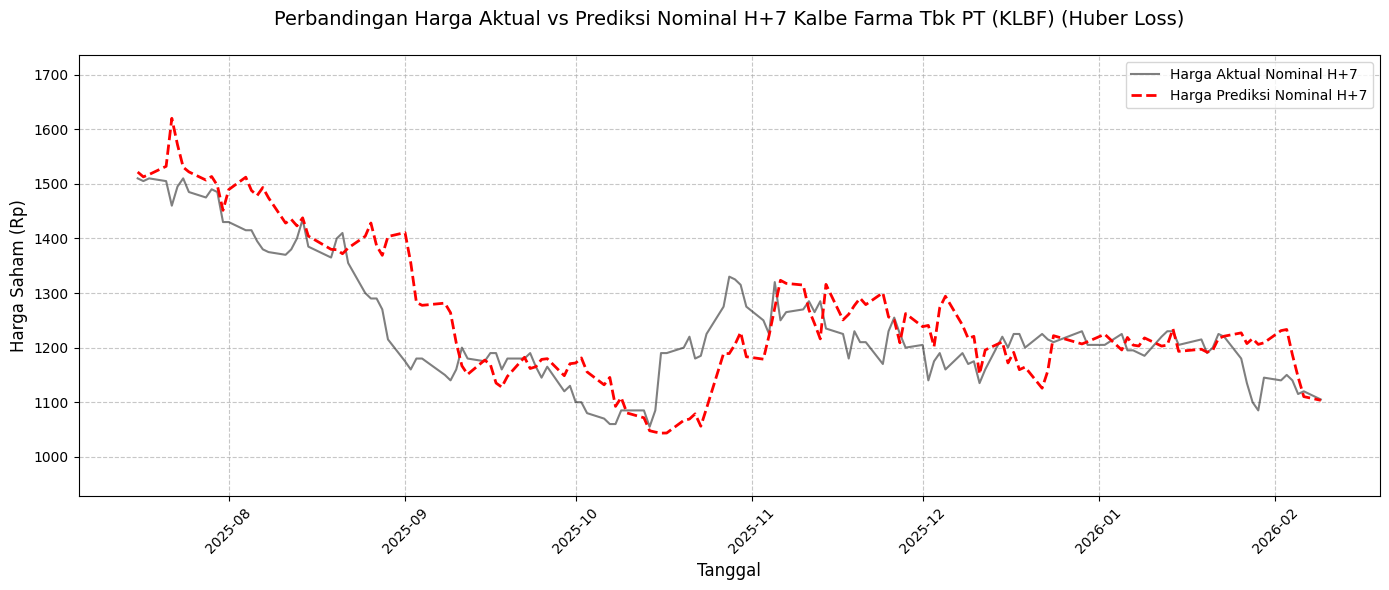

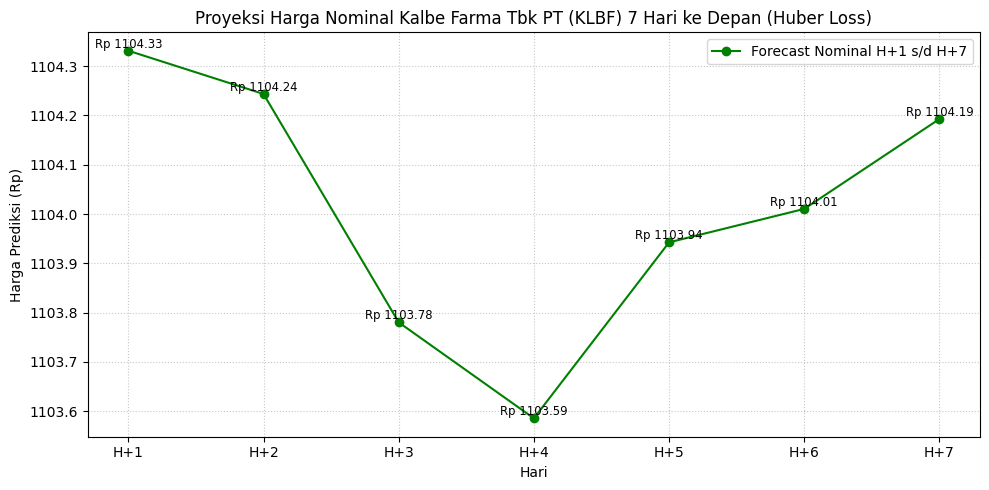


TABEL HASIL PREDIKSI NOMINAL GABUNGAN TRAIN & TEST (Kalbe Farma Tbk PT (KLBF))
  Tanggal Evaluasi Jenis Data  Aktual H+1  Prediksi H+1  Error (%) H+1  Aktual H+2  Prediksi H+2  Error (%) H+2  Aktual H+3  Prediksi H+3  Error (%) H+3  Aktual H+4  Prediksi H+4  Error (%) H+4  Aktual H+5  Prediksi H+5  Error (%) H+5  Aktual H+6  Prediksi H+6  Error (%) H+6  Aktual H+7  Prediksi H+7  Error (%) H+7
0       15-02-2023      Train      2310.0   2330.431396       0.884476      2290.0   2332.369385       1.850191      2250.0   2335.010742       3.778255      2300.0   2337.084473       1.612368      2290.0   2339.455566       2.159632      2160.0   2342.622559       8.454748      2180.0   2345.239990       7.579816
1       16-02-2023      Train      2290.0   2308.459473       0.806091      2250.0   2308.441650       2.597407      2300.0   2309.131104       0.397005      2290.0   2309.251465       0.840675      2160.0   2309.520508       6.922246      2180.0   2310.662598       5.993697      2270.

In [ ]:
import os  # Untuk manajemen direktori/folder
import joblib  # Untuk save atau load objek pendukung eksternal atau scaler data
import tensorflow as tf  # Framework utama untuk memproses model Deep Learning
import numpy as np  # Untuk manipulasi struktur data matriks (Array) sebagai input wajib model TensorFlow
import pandas as pd # Untuk mengolah hasil prediksi ke dalam bentuk tabel tabular
import matplotlib.pyplot as plt  # Modul plot grafik untuk visualisasi performa model
from tensorflow.keras.layers import LSTM, Dense, Input, Layer  # lapisan jaringan saraf untuk menyusun struktur model LSTM
from tensorflow.keras.models import Model  # Wadah untuk menyatukan seluruh lapisan menjadi satu model utuh
from tensorflow.keras.callbacks import EarlyStopping  # Tambahan Callback untuk menghentikan epoch jika jenuh
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Metrik statistik evaluasi

# Membuat Folder Saved Model dan Scaler
BASE_DIR = "saved_model"
MODEL_DIR = os.path.join(BASE_DIR, "model")
SCALER_DIR = os.path.join(BASE_DIR, "scaler")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(SCALER_DIR, exist_ok=True)


# Fungsi internal Balikin hasil prediksi scaler ke angka asli Log Return
def inverse_transform_target(y_pred, scaler_obj):
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)

    n_days = y_pred.shape[1]
    result = []

    for i in range(n_days):
        col_data = y_pred[:, i].reshape(-1, 1)
        inv = scaler_obj.inverse_transform(col_data)[:, 0]
        result.append(inv)

    return np.array(result).T


# === FUNGSI KONVERSI LOG RETURN -> SIMPLE RETURN -> HARGA NOMINAL ===
def log_return_to_nominal(y_scaled, scaler_obj, p_base_array):
    # 1. Inverse transform ke skala Log Return asli
    y_log = inverse_transform_target(y_scaled, scaler_obj)
    
    # 2. Hitung Simple Return: R_simple = exp(R_log) - 1
    y_simple = np.exp(y_log) - 1
    
    # 3. Rekonstruksi Harga Nominal secara kumulatif sekuensial (H+1 s/d H+7)
    y_nominal = np.zeros_like(y_log)
    for i in range(len(p_base_array)):
        current_price = p_base_array[i]  # Harga dasar (hari terakhir di window lookback)
        for h in range(7):
            # Harga_t = Harga_{t-1} * (1 + Simple_Return)
            current_price = current_price * (1 + y_simple[i, h])
            y_nominal[i, h] = current_price
            
    return y_nominal


# Attention Mechanism Layer
@tf.keras.utils.register_keras_serializable()
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
        
    def build(self, input_shape):
        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="normal"
        )
        self.b = self.add_weight(
            name="att_bias",
            shape=(input_shape[1], 1),
            initializer="zeros"
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(
            tf.keras.backend.dot(x, self.W) + self.b
        )
        a = tf.keras.backend.softmax(
            e,
            axis=1
        )
        output = tf.keras.backend.sum(
            x * a,
            axis=1
        )
        return output

    def get_config(self):
        config = super().get_config()
        return config


# Membuat Model
def create_model(input_shape, units, layers, lr):
    inputs = Input(shape=input_shape)
    x = inputs

    for _ in range(layers):
        x = LSTM(
            units,
            return_sequences=True
        )(x)

    x = AttentionLayer()(x)
    outputs = Dense(7)(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=lr
        ),
        loss="huber",
        metrics=["mae"]
    )
    return model


# =====================================================================
# KONFIGURASI PARAMETER
# =====================================================================
stock = "Kalbe Farma Tbk PT (KLBF)"

cfg = {
    "hidden": 32,      
    "layers": 1,       
    "lr": 0.001,       
    "win": 30          # Windowing lookback tetap 30 hari
}

# Ambil data scaled (Berisi data Log Return dari preprocessing)
data_scaled = processed_dfs[stock]["scaled"]

if data_scaled.ndim == 1:
    data_scaled = data_scaled.reshape(-1, 1)

scaler_obj = processed_dfs[stock]["scaler"]
win = cfg["win"]

# Ambil array harga nominal asli untuk menjadi jangkar (P_base) saat denormalisasi nominal
prices_nominal = processed_dfs[stock]["df"]["Terakhir"].values

X_u = []
y_u = []
P_base_u = []  # Menyimpan harga nominal hari terakhir di setiap jendela lookback

for i in range(len(data_scaled) - win - 7 + 1):
    X_u.append(data_scaled[i:i+win])  
    y_u.append(data_scaled[i+win:i+win+7, 0])  
    # Jangkar harga nominal berada pada hari terakhir dari window input (indeks: i + win - 1)
    P_base_u.append(prices_nominal[i + win - 1])

X_u = np.array(X_u)
y_u = np.array(y_u)
P_base_u = np.array(P_base_u)

# === DATA SPLITTING ===
total_len = len(processed_dfs[stock]["df"])
split_idx = int(0.8 * total_len)
split = split_idx - win

X_train = X_u[:split]
X_test = X_u[split:]

y_train = y_u[:split]
y_test = y_u[split:]

# Memisahkan jangkar harga nominal ke data train & test
P_base_train = P_base_u[:split]
P_base_test = P_base_u[split:]

print("\n===================================")
print("DATA SPLIT (UNIVARIATE LOG RETURN)")
print("===================================")
print("Train :", X_train.shape)
print("Test  :", X_test.shape)

df_dates = processed_dfs[stock]["df"]["Tanggal"].reset_index(drop=True)

train_start_date = df_dates.iloc[0]
train_end_date = df_dates.iloc[split_idx - 1]

test_start_date = df_dates.iloc[split_idx]
test_end_date = df_dates.iloc[-1]

print("\n===================================")
print("RENTANG TANGGAL DATASET")
print("===================================")
print(f"Data Latih (Train) : {train_start_date.strftime('%d %B %Y')} s/d {train_end_date.strftime('%d %B %Y')}")
print(f"Data Uji (Test)    : {test_start_date.strftime('%d %B %Y')} s/d {test_end_date.strftime('%d %B %Y')}")

# Melatih model
model_u = create_model(
    input_shape=(win, 1),
    units=cfg["hidden"],
    layers=cfg["layers"],
    lr=cfg["lr"]
)

print("\n===================================")
print(f"SUMMARY MODEL {stock}")
print("===================================")
model_u.summary()

# Menambahkan callback Early Stopping untuk memantau data validasi
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True, 
    verbose=1
)

# Memulai Proses Training
print(f"\nTraining model {stock} dengan Huber Loss...")
history = model_u.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,                 # Menggunakan 50 epoch sesuai instruksi sebelumnya
    batch_size=32,
    shuffle=False,
    callbacks=[early_stop], 
    verbose=1
)

# Simpan Model & Scaler
model_path = os.path.join(MODEL_DIR, f"{stock}_lstm_attention_huber.keras")
model_u.save(model_path)

scaler_path = os.path.join(SCALER_DIR, f"{stock}_scaler_huber.pkl")
joblib.dump(scaler_obj, scaler_path)

# Membuat Prediksi mentah (skala Log Return ternormalisasi)
preds = model_u.predict(X_test, verbose=0)
preds_train = model_u.predict(X_train, verbose=0)

# === PROSES UTAMA: KONVERSI HASIL KE HARGA NOMINAL RUPIAH ===
y_test_inv = log_return_to_nominal(y_test, scaler_obj, P_base_test)
preds_inv = log_return_to_nominal(preds, scaler_obj, P_base_test)

y_train_inv = log_return_to_nominal(y_train, scaler_obj, P_base_train)
preds_train_inv = log_return_to_nominal(preds_train, scaler_obj, P_base_train)


# === REVISI EVALUASI BERDASARKAN HARGA NOMINAL ===
print("\n=========================================================================")
print("HASIL EVALUASI MODEL DALAM SKALA HARGA NOMINAL RUPIAH (H+1 s/d H+7)")
print("=========================================================================")
print(f"{'Horizon':<10}{'MAE (Test)':<15}{'RMSE (Test)':<15}{'MAPE (Test)':<15}{'R2 (Train)':<15}")
print("-" * 72)

for h in range(7):
    y_true_step = y_test_inv[:, h]
    y_pred_step = preds_inv[:, h]
    y_true_safe = np.where(y_true_step == 0, 1e-8, y_true_step)
    
    mae_step = mean_absolute_error(y_true_step, y_pred_step)
    rmse_step = np.sqrt(mean_squared_error(y_true_step, y_pred_step))
    mape_step = np.mean(np.abs((y_true_step - y_pred_step) / y_true_safe)) * 100
    
    y_true_train_step = y_train_inv[:, h]
    y_pred_train_step = preds_train_inv[:, h]
    r2_step = r2_score(y_true_train_step, y_pred_train_step)
    
    print(f"H+{h+1:<8}{mae_step:<15.2f}{rmse_step:<15.2f}{mape_step:<14.2f}%{r2_step:<15.4f}")


# Prediksi Masa Depan (H+1 s/d H+7) dari baris paling terakhir data
last_window = data_scaled[-win:].reshape(1, win, 1)
future_pred = model_u.predict(last_window, verbose=0)

# Jangkar untuk masa depan adalah harga penutupan paling terakhir di dataset asli
last_nominal_price = processed_dfs[stock]["df"]["Terakhir"].iloc[-1]
future_prices = log_return_to_nominal(future_pred, scaler_obj, [last_nominal_price]).flatten()

print("\n===================================")
print("HASIL PREDIKSI MASA DEPAN NOMINAL (H+1 s/d H+7)")
print("===================================")
for h in range(7):
    print(f"Prediksi Harga H+{h+1} : Rp {future_prices[h]:.2f}")

# === PLOT GRAFIK HARGA NOMINAL H+7 ===
plt.figure(figsize=(14, 6))
test_dates_h7 = df_dates.iloc[split_idx + 6 : split_idx + 6 + len(preds_inv)].reset_index(drop=True)

plt.plot(test_dates_h7.values, y_test_inv[:, 6], label='Harga Aktual Nominal H+7', color='black', alpha=0.5, linewidth=1.5)
plt.plot(test_dates_h7.values, preds_inv[:, 6], label='Harga Prediksi Nominal H+7', color='red', linestyle='--', linewidth=2)

plt.title(f'Perbandingan Harga Aktual vs Prediksi Nominal H+7 {stock} (Huber Loss)\n', fontsize=14)
plt.xlabel('Tanggal', fontsize=12) 
plt.ylabel('Harga Saham (Rp)', fontsize=12)

y_min = min(np.min(y_test_inv[:, 6]), np.min(preds_inv[:, 6]))
y_max = max(np.max(y_test_inv[:, 6]), np.max(preds_inv[:, 6]))
buffer = (y_max - y_min) * 0.2  
plt.ylim(y_min - buffer, y_max + buffer)

plt.xticks(rotation=45) 
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() 
plt.show()

# === PLOT GRAFIK FORECAST 7 HARI KE DEPAN ===
plt.figure(figsize=(10, 5))
x = np.arange(1, 8)
plt.plot(x, future_prices, marker='o', linestyle='-', color='green', label='Forecast Nominal H+1 s/d H+7')
plt.xticks(x, [f'H+{i}' for i in range(1, 8)])
plt.title(f'Proyeksi Harga Nominal {stock} 7 Hari ke Depan (Huber Loss)')
plt.xlabel('Hari')
plt.ylabel('Harga Prediksi (Rp)')

for i, price in enumerate(future_prices):
    plt.text(i + 1, price, f'Rp {price:.2f}', ha='center', va='bottom', fontsize='small')

plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# === PEMBUATAN TABEL EXCEL NOMINAL ===
window_size = win 
train_dates = df_dates.iloc[window_size : window_size + len(preds_train_inv)].reset_index(drop=True)
test_dates = df_dates.iloc[split_idx : split_idx + len(preds_inv)].reset_index(drop=True)

df_train = pd.DataFrame({
    'Tanggal Evaluasi': train_dates.dt.strftime('%d-%m-%Y'),
    'Jenis Data': 'Train'
})

for h in range(7):
    df_train[f'Aktual H+{h+1}'] = y_train_inv[:, h]
    df_train[f'Prediksi H+{h+1}'] = preds_train_inv[:, h]
    df_train[f'Error (%) H+{h+1}'] = (np.abs(y_train_inv[:, h] - preds_train_inv[:, h]) / np.where(y_train_inv[:, h] == 0, 1e-8, y_train_inv[:, h])) * 100

df_test = pd.DataFrame({
    'Tanggal Evaluasi': test_dates.dt.strftime('%d-%m-%Y'),
    'Jenis Data': 'Test'
})

for h in range(7):
    df_test[f'Aktual H+{h+1}'] = y_test_inv[:, h]
    df_test[f'Prediksi H+{h+1}'] = preds_inv[:, h]
    df_test[f'Error (%) H+{h+1}'] = (np.abs(y_test_inv[:, h] - preds_inv[:, h]) / np.where(y_test_inv[:, h] == 0, 1e-8, y_test_inv[:, h])) * 100

df_hasil_per_baris = pd.concat([df_train, df_test], ignore_index=True)

print("\n=====================================================================")
print(f"TABEL HASIL PREDIKSI NOMINAL GABUNGAN TRAIN & TEST ({stock})")
print("=====================================================================")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', 10) 
print(df_hasil_per_baris.head(10))

excel_output_path = os.path.join(BASE_DIR, "Hasil_Prediksi_KLBF_HuberLoss.xlsx")
try:
    df_hasil_per_baris.to_excel(excel_output_path, index=False)
    print(f"\nHasil lengkap nominal rupiah berhasil diekspor ke: {excel_output_path}")
except PermissionError:
    print(f"\nERROR: Gagal menyimpan ke {excel_output_path}. Pastikan file tidak sedang dibuka.")


DATA SPLIT (UNIVARIATE LOG RETURN)
Train : (559, 30, 1)
Test  : (142, 30, 1)

RENTANG TANGGAL DATASET
Data Latih (Train) : 03 January 2023 s/d 07 July 2025
Data Uji (Test)    : 08 July 2025 s/d 09 February 2026

SUMMARY MODEL Phapros Tbk PT (PEHA)


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 30, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer_7               │ (None, 32)             │            62 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,645 (18.14 KB)

 Trainable params: 4,645 (18.14 KB)

 Non-trainable params: 0 (0.00 B)


Training model Phapros Tbk PT (PEHA) dengan Huber Loss...
Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 0.0695 - mae: 0.3469 - val_loss: 0.0448 - val_mae: 0.2499
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0268 - mae: 0.1870 - val_loss: 0.0122 - val_mae: 0.1225
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0055 - mae: 0.0713 - val_loss: 0.0042 - val_mae: 0.0593
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0035 - mae: 0.0513 - val_loss: 0.0038 - val_mae: 0.0519
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0031 - mae: 0.0430 - val_loss: 0.0037 - val_mae: 0.0486
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0030 - mae: 0.0399 - val_loss: 0.0036 - val_mae: 0.0477
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0030 - mae: 0.0394 - val_loss: 0.0036 - val_mae: 0.0473
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0030 - mae: 0.0392 - val_loss: 0.0036 - val_mae: 0.0474
Epoch

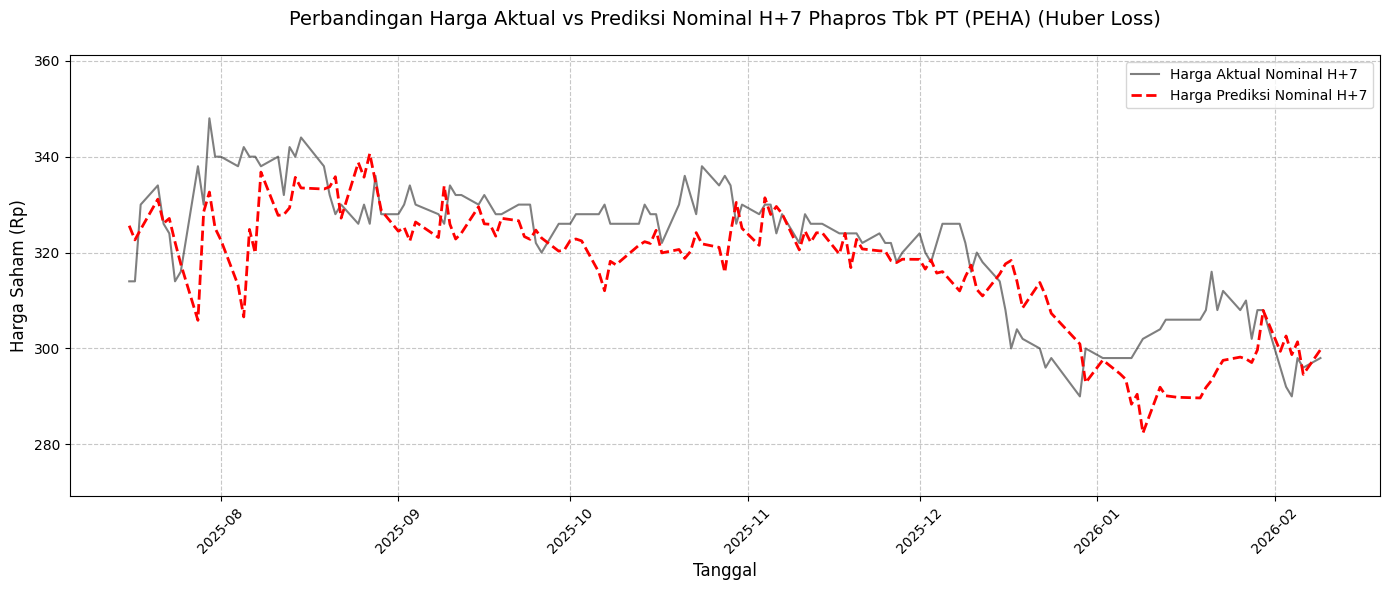

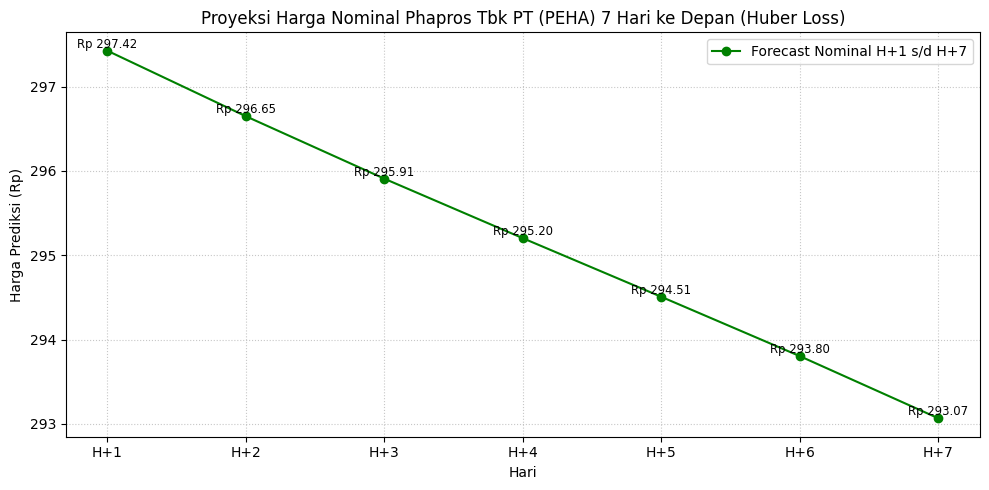


TABEL HASIL PREDIKSI NOMINAL GABUNGAN TRAIN & TEST (Phapros Tbk PT (PEHA))
  Tanggal Evaluasi Jenis Data  Aktual H+1  Prediksi H+1  Error (%) H+1  Aktual H+2  Prediksi H+2  Error (%) H+2  Aktual H+3  Prediksi H+3  Error (%) H+3  Aktual H+4  Prediksi H+4  Error (%) H+4  Aktual H+5  Prediksi H+5  Error (%) H+5  Aktual H+6  Prediksi H+6  Error (%) H+6  Aktual H+7  Prediksi H+7  Error (%) H+7
0       15-02-2023      Train       700.0    698.967468       0.147505       695.0    697.596191       0.373553       695.0    696.125488       0.161941       685.0    694.893311       1.444279       690.0    693.729004       0.540435       700.0    692.238220       1.108826       700.0    690.975891       1.289158
1       16-02-2023      Train       695.0    698.704895       0.533078       695.0    697.054321       0.295586       685.0    695.337280       1.509092       690.0    693.841431       0.556729       700.0    692.397522       1.086068       700.0    690.660767       1.334176       695.0   

In [9]:
import os  # Untuk manajemen direktori/folder
import joblib  # Untuk save atau load objek pendukung eksternal atau scaler data
import tensorflow as tf  # Framework utama untuk memproses model Deep Learning
import numpy as np  # Untuk manipulasi struktur data matriks (Array) sebagai input wajib model TensorFlow
import pandas as pd # Untuk mengolah hasil prediksi ke dalam bentuk tabel tabular
import matplotlib.pyplot as plt  # Modul plot grafik untuk visualisasi performa model
from tensorflow.keras.layers import LSTM, Dense, Input, Layer  # lapisan jaringan saraf untuk menyusun struktur model LSTM
from tensorflow.keras.models import Model  # Wadah untuk menyatukan seluruh lapisan menjadi satu model utuh
from tensorflow.keras.callbacks import EarlyStopping  # Tambahan Callback untuk menghentikan epoch jika jenuh
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Metrik statistik evaluasi

# Membuat Folder Saved Model dan Scaler
BASE_DIR = "saved_model"
MODEL_DIR = os.path.join(BASE_DIR, "model")
SCALER_DIR = os.path.join(BASE_DIR, "scaler")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(SCALER_DIR, exist_ok=True)


# Fungsi internal Balikin hasil prediksi scaler ke angka asli Log Return
def inverse_transform_target(y_pred, scaler_obj):
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)

    n_days = y_pred.shape[1]
    result = []

    for i in range(n_days):
        col_data = y_pred[:, i].reshape(-1, 1)
        inv = scaler_obj.inverse_transform(col_data)[:, 0]
        result.append(inv)

    return np.array(result).T


# === FUNGSI KONVERSI LOG RETURN -> SIMPLE RETURN -> HARGA NOMINAL ===
def log_return_to_nominal(y_scaled, scaler_obj, p_base_array):
    # 1. Inverse transform ke skala Log Return asli
    y_log = inverse_transform_target(y_scaled, scaler_obj)
    
    # 2. Hitung Simple Return: R_simple = exp(R_log) - 1
    y_simple = np.exp(y_log) - 1
    
    # 3. Rekonstruksi Harga Nominal secara kumulatif sekuensial (H+1 s/d H+7)
    y_nominal = np.zeros_like(y_log)
    for i in range(len(p_base_array)):
        current_price = p_base_array[i]  # Harga dasar (hari terakhir di window lookback)
        for h in range(7):
            # Harga_t = Harga_{t-1} * (1 + Simple_Return)
            current_price = current_price * (1 + y_simple[i, h])
            y_nominal[i, h] = current_price
            
    return y_nominal


# Attention Mechanism Layer
@tf.keras.utils.register_keras_serializable()
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
        
    def build(self, input_shape):
        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="normal"
        )
        self.b = self.add_weight(
            name="att_bias",
            shape=(input_shape[1], 1),
            initializer="zeros"
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(
            tf.keras.backend.dot(x, self.W) + self.b
        )
        a = tf.keras.backend.softmax(
            e,
            axis=1
        )
        output = tf.keras.backend.sum(
            x * a,
            axis=1
        )
        return output

    def get_config(self):
        config = super().get_config()
        return config


# Membuat Model
def create_model(input_shape, units, layers, lr):
    inputs = Input(shape=input_shape)
    x = inputs

    for _ in range(layers):
        x = LSTM(
            units,
            return_sequences=True
        )(x)

    x = AttentionLayer()(x)
    outputs = Dense(7)(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=lr
        ),
        loss="huber",  # PERUBAHAN: Mengubah "mse" menjadi "huber" agar lebih mengikuti volatilitas tajam
        metrics=["mae"]
    )
    return model


# =====================================================================
# KONFIGURASI PARAMETER
# =====================================================================
stock = "Phapros Tbk PT (PEHA)"

cfg = {
    "hidden": 32,      
    "layers": 1,       
    "lr": 0.001,       
    "win": 30          # Windowing lookback tetap 30 hari
}

# Ambil data scaled (Berisi data Log Return dari preprocessing)
data_scaled = processed_dfs[stock]["scaled"]

if data_scaled.ndim == 1:
    data_scaled = data_scaled.reshape(-1, 1)

scaler_obj = processed_dfs[stock]["scaler"]
win = cfg["win"]

# Ambil array harga nominal asli untuk menjadi jangkar (P_base) saat denormalisasi nominal
prices_nominal = processed_dfs[stock]["df"]["Terakhir"].values

X_u = []
y_u = []
P_base_u = []  # Menyimpan harga nominal hari terakhir di setiap jendela lookback

for i in range(len(data_scaled) - win - 7 + 1):
    X_u.append(data_scaled[i:i+win])  
    y_u.append(data_scaled[i+win:i+win+7, 0])  
    # Jangkar harga nominal berada pada hari terakhir dari window input (indeks: i + win - 1)
    P_base_u.append(prices_nominal[i + win - 1])

X_u = np.array(X_u)
y_u = np.array(y_u)
P_base_u = np.array(P_base_u)

# === DATA SPLITTING ===
total_len = len(processed_dfs[stock]["df"])
split_idx = int(0.8 * total_len)
split = split_idx - win

X_train = X_u[:split]
X_test = X_u[split:]

y_train = y_u[:split]
y_test = y_u[split:]

# Memisahkan jangkar harga nominal ke data train & test
P_base_train = P_base_u[:split]
P_base_test = P_base_u[split:]

print("\n===================================")
print("DATA SPLIT (UNIVARIATE LOG RETURN)")
print("===================================")
print("Train :", X_train.shape)
print("Test  :", X_test.shape)

df_dates = processed_dfs[stock]["df"]["Tanggal"].reset_index(drop=True)

train_start_date = df_dates.iloc[0]
train_end_date = df_dates.iloc[split_idx - 1]

test_start_date = df_dates.iloc[split_idx]
test_end_date = df_dates.iloc[-1]

print("\n===================================")
print("RENTANG TANGGAL DATASET")
print("===================================")
print(f"Data Latih (Train) : {train_start_date.strftime('%d %B %Y')} s/d {train_end_date.strftime('%d %B %Y')}")
print(f"Data Uji (Test)    : {test_start_date.strftime('%d %B %Y')} s/d {test_end_date.strftime('%d %B %Y')}")

# Melatih model
model_u = create_model(
    input_shape=(win, 1),
    units=cfg["hidden"],
    layers=cfg["layers"],
    lr=cfg["lr"]
)

print("\n===================================")
print(f"SUMMARY MODEL {stock}")
print("===================================")
model_u.summary()

# Menambahkan callback Early Stopping untuk memantau data validasi
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True, 
    verbose=1
)

# Memulai Proses Training
print(f"\nTraining model {stock} dengan Huber Loss...")
history = model_u.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,                 # Menggunakan 50 epoch sesuai instruksi sebelumnya
    batch_size=32,
    shuffle=False,
    callbacks=[early_stop], 
    verbose=1
)

# Simpan Model & Scaler
model_path = os.path.join(MODEL_DIR, f"{stock}_lstm_attention_huber.keras")
model_u.save(model_path)

scaler_path = os.path.join(SCALER_DIR, f"{stock}_scaler_huber.pkl")
joblib.dump(scaler_obj, scaler_path)

# Membuat Prediksi mentah (skala Log Return ternormalisasi)
preds = model_u.predict(X_test, verbose=0)
preds_train = model_u.predict(X_train, verbose=0)

# === PROSES UTAMA: KONVERSI HASIL KE HARGA NOMINAL RUPIAH ===
y_test_inv = log_return_to_nominal(y_test, scaler_obj, P_base_test)
preds_inv = log_return_to_nominal(preds, scaler_obj, P_base_test)

y_train_inv = log_return_to_nominal(y_train, scaler_obj, P_base_train)
preds_train_inv = log_return_to_nominal(preds_train, scaler_obj, P_base_train)


# === REVISI EVALUASI BERDASARKAN HARGA NOMINAL ===
print("\n=========================================================================")
print("HASIL EVALUASI MODEL DALAM SKALA HARGA NOMINAL RUPIAH (H+1 s/d H+7)")
print("=========================================================================")
print(f"{'Horizon':<10}{'MAE (Test)':<15}{'RMSE (Test)':<15}{'MAPE (Test)':<15}{'R2 (Train)':<15}")
print("-" * 72)

for h in range(7):
    y_true_step = y_test_inv[:, h]
    y_pred_step = preds_inv[:, h]
    y_true_safe = np.where(y_true_step == 0, 1e-8, y_true_step)
    
    mae_step = mean_absolute_error(y_true_step, y_pred_step)
    rmse_step = np.sqrt(mean_squared_error(y_true_step, y_pred_step))
    mape_step = np.mean(np.abs((y_true_step - y_pred_step) / y_true_safe)) * 100
    
    y_true_train_step = y_train_inv[:, h]
    y_pred_train_step = preds_train_inv[:, h]
    r2_step = r2_score(y_true_train_step, y_pred_train_step)
    
    print(f"H+{h+1:<8}{mae_step:<15.2f}{rmse_step:<15.2f}{mape_step:<14.2f}%{r2_step:<15.4f}")


# Prediksi Masa Depan (H+1 s/d H+7) dari baris paling terakhir data
last_window = data_scaled[-win:].reshape(1, win, 1)
future_pred = model_u.predict(last_window, verbose=0)

# Jangkar untuk masa depan adalah harga penutupan paling terakhir di dataset asli
last_nominal_price = processed_dfs[stock]["df"]["Terakhir"].iloc[-1]
future_prices = log_return_to_nominal(future_pred, scaler_obj, [last_nominal_price]).flatten()

print("\n===================================")
print("HASIL PREDIKSI MASA DEPAN NOMINAL (H+1 s/d H+7)")
print("===================================")
for h in range(7):
    print(f"Prediksi Harga H+{h+1} : Rp {future_prices[h]:.2f}")

# === PLOT GRAFIK HARGA NOMINAL H+7 ===
plt.figure(figsize=(14, 6))
test_dates_h7 = df_dates.iloc[split_idx + 6 : split_idx + 6 + len(preds_inv)].reset_index(drop=True)

plt.plot(test_dates_h7.values, y_test_inv[:, 6], label='Harga Aktual Nominal H+7', color='black', alpha=0.5, linewidth=1.5)
plt.plot(test_dates_h7.values, preds_inv[:, 6], label='Harga Prediksi Nominal H+7', color='red', linestyle='--', linewidth=2)

plt.title(f'Perbandingan Harga Aktual vs Prediksi Nominal H+7 {stock} (Huber Loss)\n', fontsize=14)
plt.xlabel('Tanggal', fontsize=12) 
plt.ylabel('Harga Saham (Rp)', fontsize=12)

y_min = min(np.min(y_test_inv[:, 6]), np.min(preds_inv[:, 6]))
y_max = max(np.max(y_test_inv[:, 6]), np.max(preds_inv[:, 6]))
buffer = (y_max - y_min) * 0.2  
plt.ylim(y_min - buffer, y_max + buffer)

plt.xticks(rotation=45) 
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() 
plt.show()

# === PLOT GRAFIK FORECAST 7 HARI KE DEPAN ===
plt.figure(figsize=(10, 5))
x = np.arange(1, 8)
plt.plot(x, future_prices, marker='o', linestyle='-', color='green', label='Forecast Nominal H+1 s/d H+7')
plt.xticks(x, [f'H+{i}' for i in range(1, 8)])
plt.title(f'Proyeksi Harga Nominal {stock} 7 Hari ke Depan (Huber Loss)')
plt.xlabel('Hari')
plt.ylabel('Harga Prediksi (Rp)')

for i, price in enumerate(future_prices):
    plt.text(i + 1, price, f'Rp {price:.2f}', ha='center', va='bottom', fontsize='small')

plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# === PEMBUATAN TABEL EXCEL NOMINAL ===
window_size = win 
train_dates = df_dates.iloc[window_size : window_size + len(preds_train_inv)].reset_index(drop=True)
test_dates = df_dates.iloc[split_idx : split_idx + len(preds_inv)].reset_index(drop=True)

df_train = pd.DataFrame({
    'Tanggal Evaluasi': train_dates.dt.strftime('%d-%m-%Y'),
    'Jenis Data': 'Train'
})

for h in range(7):
    df_train[f'Aktual H+{h+1}'] = y_train_inv[:, h]
    df_train[f'Prediksi H+{h+1}'] = preds_train_inv[:, h]
    df_train[f'Error (%) H+{h+1}'] = (np.abs(y_train_inv[:, h] - preds_train_inv[:, h]) / np.where(y_train_inv[:, h] == 0, 1e-8, y_train_inv[:, h])) * 100

df_test = pd.DataFrame({
    'Tanggal Evaluasi': test_dates.dt.strftime('%d-%m-%Y'),
    'Jenis Data': 'Test'
})

for h in range(7):
    df_test[f'Aktual H+{h+1}'] = y_test_inv[:, h]
    df_test[f'Prediksi H+{h+1}'] = preds_inv[:, h]
    df_test[f'Error (%) H+{h+1}'] = (np.abs(y_test_inv[:, h] - preds_inv[:, h]) / np.where(y_test_inv[:, h] == 0, 1e-8, y_test_inv[:, h])) * 100

df_hasil_per_baris = pd.concat([df_train, df_test], ignore_index=True)

print("\n=====================================================================")
print(f"TABEL HASIL PREDIKSI NOMINAL GABUNGAN TRAIN & TEST ({stock})")
print("=====================================================================")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', 10) 
print(df_hasil_per_baris.head(10))

excel_output_path = os.path.join(BASE_DIR, "Hasil_Prediksi_PEHA_HuberLoss.xlsx")
try:
    df_hasil_per_baris.to_excel(excel_output_path, index=False)
    print(f"\nHasil lengkap nominal rupiah berhasil diekspor ke: {excel_output_path}")
except PermissionError:
    print(f"\nERROR: Gagal menyimpan ke {excel_output_path}. Pastikan file tidak sedang dibuka.")


DATA SPLIT (UNIVARIATE LOG RETURN)
Train : (559, 30, 1)
Test  : (142, 30, 1)

RENTANG TANGGAL DATASET
Data Latih (Train) : 03 January 2023 s/d 07 July 2025
Data Uji (Test)    : 08 July 2025 s/d 09 February 2026

SUMMARY MODEL Sido Muncul Tbk PT (SIDO)


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 30, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer_8               │ (None, 32)             │            62 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,645 (18.14 KB)

 Trainable params: 4,645 (18.14 KB)

 Non-trainable params: 0 (0.00 B)


Training model Sido Muncul Tbk PT (SIDO) dengan Huber Loss...
Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 0.1810 - mae: 0.5886 - val_loss: 0.1414 - val_mae: 0.5182
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1119 - mae: 0.4576 - val_loss: 0.0744 - val_mae: 0.3632
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0395 - mae: 0.2407 - val_loss: 0.0171 - val_mae: 0.1547
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0092 - mae: 0.1040 - val_loss: 0.0067 - val_mae: 0.0857
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0060 - mae: 0.0806 - val_loss: 0.0062 - val_mae: 0.0813
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0052 - mae: 0.0731 - val_loss: 0.0058 - val_mae: 0.0776
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0051 - mae: 0.0714 - val_loss: 0.0058 - val_mae: 0.0767
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0050 - mae: 0.0708 - val_loss: 0.0058 - val_mae: 0.0762
E

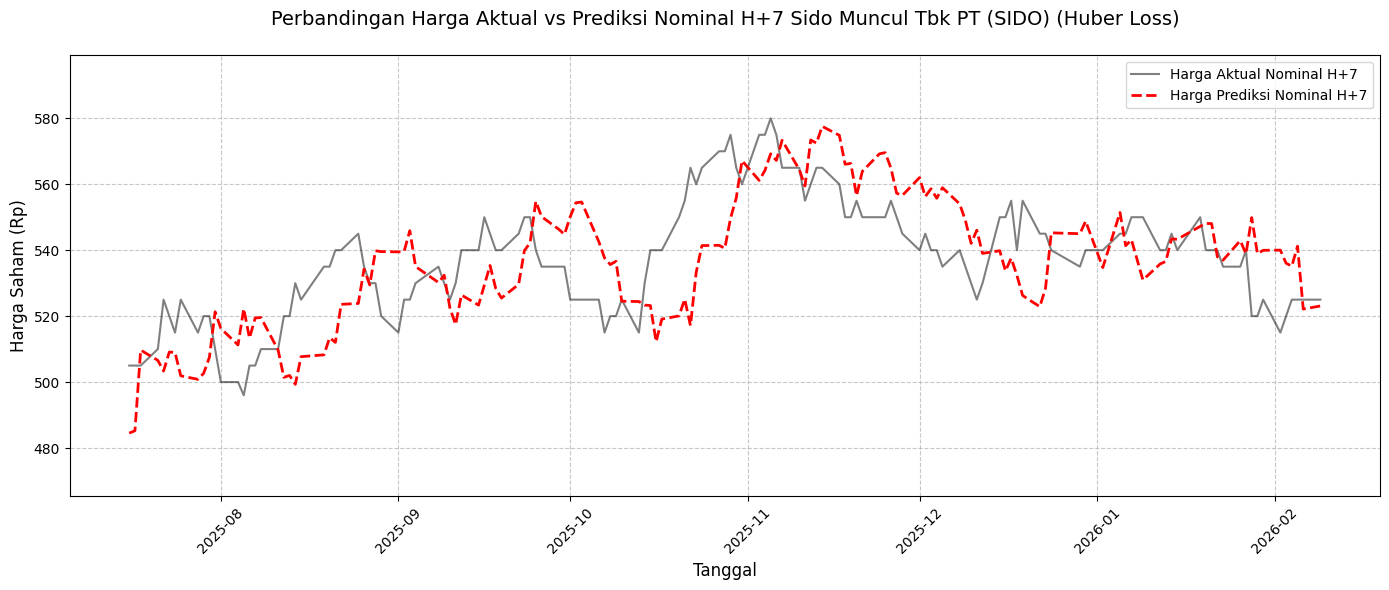

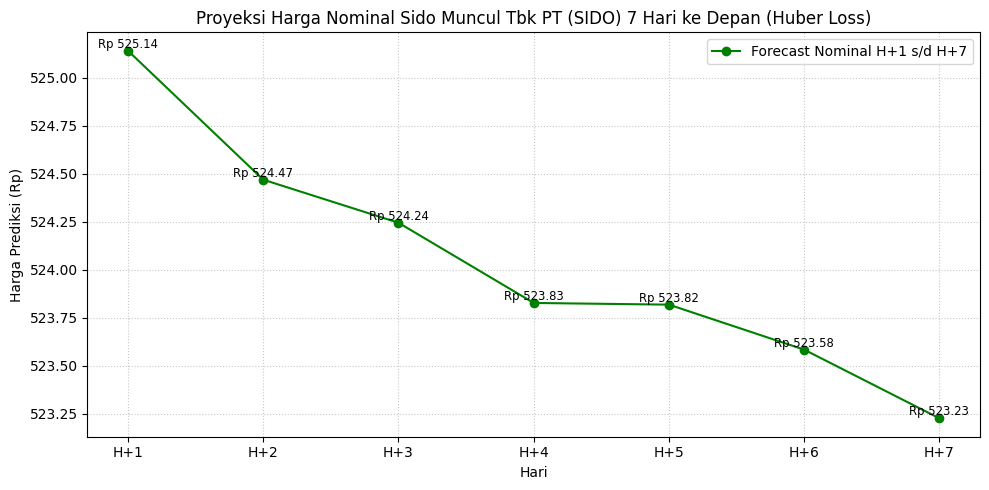


TABEL HASIL PREDIKSI NOMINAL GABUNGAN TRAIN & TEST (Sido Muncul Tbk PT (SIDO))
  Tanggal Evaluasi Jenis Data  Aktual H+1  Prediksi H+1  Error (%) H+1  Aktual H+2  Prediksi H+2  Error (%) H+2  Aktual H+3  Prediksi H+3  Error (%) H+3  Aktual H+4  Prediksi H+4  Error (%) H+4  Aktual H+5  Prediksi H+5  Error (%) H+5  Aktual H+6  Prediksi H+6  Error (%) H+6  Aktual H+7  Prediksi H+7  Error (%) H+7
0       15-02-2023      Train       870.0    870.114929       0.013210       890.0    870.039917       2.242706       870.0    869.852234       0.016985       860.0    869.200684       1.069847       865.0    870.259155       0.607995       880.0    870.351990       1.096365       880.0    870.101074       1.124878
1       16-02-2023      Train       890.0    870.132263       2.232330       870.0    870.180969       0.020801       860.0    870.053528       1.169015       865.0    869.450195       0.514473       880.0    870.636230       1.064065       880.0    870.793579       1.046184       865.

In [10]:
import os  # Untuk manajemen direktori/folder
import joblib  # Untuk save atau load objek pendukung eksternal atau scaler data
import tensorflow as tf  # Framework utama untuk memproses model Deep Learning
import numpy as np  # Untuk manipulasi struktur data matriks (Array) sebagai input wajib model TensorFlow
import pandas as pd # Untuk mengolah hasil prediksi ke dalam bentuk tabel tabular
import matplotlib.pyplot as plt  # Modul plot grafik untuk visualisasi performa model
from tensorflow.keras.layers import LSTM, Dense, Input, Layer  # lapisan jaringan saraf untuk menyusun struktur model LSTM
from tensorflow.keras.models import Model  # Wadah untuk menyatukan seluruh lapisan menjadi satu model utuh
from tensorflow.keras.callbacks import EarlyStopping  # Tambahan Callback untuk menghentikan epoch jika jenuh
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Metrik statistik evaluasi

# Membuat Folder Saved Model dan Scaler
BASE_DIR = "saved_model"
MODEL_DIR = os.path.join(BASE_DIR, "model")
SCALER_DIR = os.path.join(BASE_DIR, "scaler")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(SCALER_DIR, exist_ok=True)


# Fungsi internal Balikin hasil prediksi scaler ke angka asli Log Return
def inverse_transform_target(y_pred, scaler_obj):
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)

    n_days = y_pred.shape[1]
    result = []

    for i in range(n_days):
        col_data = y_pred[:, i].reshape(-1, 1)
        inv = scaler_obj.inverse_transform(col_data)[:, 0]
        result.append(inv)

    return np.array(result).T


# === FUNGSI KONVERSI LOG RETURN -> SIMPLE RETURN -> HARGA NOMINAL ===
def log_return_to_nominal(y_scaled, scaler_obj, p_base_array):
    # 1. Inverse transform ke skala Log Return asli
    y_log = inverse_transform_target(y_scaled, scaler_obj)
    
    # 2. Hitung Simple Return: R_simple = exp(R_log) - 1
    y_simple = np.exp(y_log) - 1
    
    # 3. Rekonstruksi Harga Nominal secara kumulatif sekuensial (H+1 s/d H+7)
    y_nominal = np.zeros_like(y_log)
    for i in range(len(p_base_array)):
        current_price = p_base_array[i]  # Harga dasar (hari terakhir di window lookback)
        for h in range(7):
            # Harga_t = Harga_{t-1} * (1 + Simple_Return)
            current_price = current_price * (1 + y_simple[i, h])
            y_nominal[i, h] = current_price
            
    return y_nominal


# Attention Mechanism Layer
@tf.keras.utils.register_keras_serializable()
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
        
    def build(self, input_shape):
        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="normal"
        )
        self.b = self.add_weight(
            name="att_bias",
            shape=(input_shape[1], 1),
            initializer="zeros"
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(
            tf.keras.backend.dot(x, self.W) + self.b
        )
        a = tf.keras.backend.softmax(
            e,
            axis=1
        )
        output = tf.keras.backend.sum(
            x * a,
            axis=1
        )
        return output

    def get_config(self):
        config = super().get_config()
        return config


# Membuat Model
def create_model(input_shape, units, layers, lr):
    inputs = Input(shape=input_shape)
    x = inputs

    for _ in range(layers):
        x = LSTM(
            units,
            return_sequences=True
        )(x)

    x = AttentionLayer()(x)
    outputs = Dense(7)(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=lr
        ),
        loss="huber",  # PERUBAHAN: Mengubah "mse" menjadi "huber" agar lebih mengikuti volatilitas tajam
        metrics=["mae"]
    )
    return model


# =====================================================================
# KONFIGURASI PARAMETER
# =====================================================================
stock = "Sido Muncul Tbk PT (SIDO)"

cfg = {
    "hidden": 32,      
    "layers": 1,       
    "lr": 0.001,       
    "win": 30          # Windowing lookback tetap 30 hari
}

# Ambil data scaled (Berisi data Log Return dari preprocessing)
data_scaled = processed_dfs[stock]["scaled"]

if data_scaled.ndim == 1:
    data_scaled = data_scaled.reshape(-1, 1)

scaler_obj = processed_dfs[stock]["scaler"]
win = cfg["win"]

# Ambil array harga nominal asli untuk menjadi jangkar (P_base) saat denormalisasi nominal
prices_nominal = processed_dfs[stock]["df"]["Terakhir"].values

X_u = []
y_u = []
P_base_u = []  # Menyimpan harga nominal hari terakhir di setiap jendela lookback

for i in range(len(data_scaled) - win - 7 + 1):
    X_u.append(data_scaled[i:i+win])  
    y_u.append(data_scaled[i+win:i+win+7, 0])  
    # Jangkar harga nominal berada pada hari terakhir dari window input (indeks: i + win - 1)
    P_base_u.append(prices_nominal[i + win - 1])

X_u = np.array(X_u)
y_u = np.array(y_u)
P_base_u = np.array(P_base_u)

# === DATA SPLITTING ===
total_len = len(processed_dfs[stock]["df"])
split_idx = int(0.8 * total_len)
split = split_idx - win

X_train = X_u[:split]
X_test = X_u[split:]

y_train = y_u[:split]
y_test = y_u[split:]

# Memisahkan jangkar harga nominal ke data train & test
P_base_train = P_base_u[:split]
P_base_test = P_base_u[split:]

print("\n===================================")
print("DATA SPLIT (UNIVARIATE LOG RETURN)")
print("===================================")
print("Train :", X_train.shape)
print("Test  :", X_test.shape)

df_dates = processed_dfs[stock]["df"]["Tanggal"].reset_index(drop=True)

train_start_date = df_dates.iloc[0]
train_end_date = df_dates.iloc[split_idx - 1]

test_start_date = df_dates.iloc[split_idx]
test_end_date = df_dates.iloc[-1]

print("\n===================================")
print("RENTANG TANGGAL DATASET")
print("===================================")
print(f"Data Latih (Train) : {train_start_date.strftime('%d %B %Y')} s/d {train_end_date.strftime('%d %B %Y')}")
print(f"Data Uji (Test)    : {test_start_date.strftime('%d %B %Y')} s/d {test_end_date.strftime('%d %B %Y')}")

# Melatih model
model_u = create_model(
    input_shape=(win, 1),
    units=cfg["hidden"],
    layers=cfg["layers"],
    lr=cfg["lr"]
)

print("\n===================================")
print(f"SUMMARY MODEL {stock}")
print("===================================")
model_u.summary()

# Menambahkan callback Early Stopping untuk memantau data validasi
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True, 
    verbose=1
)

# Memulai Proses Training
print(f"\nTraining model {stock} dengan Huber Loss...")
history = model_u.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,                 # Menggunakan 50 epoch sesuai instruksi sebelumnya
    batch_size=32,
    shuffle=False,
    callbacks=[early_stop], 
    verbose=1
)

# Simpan Model & Scaler
model_path = os.path.join(MODEL_DIR, f"{stock}_lstm_attention_huber.keras")
model_u.save(model_path)

scaler_path = os.path.join(SCALER_DIR, f"{stock}_scaler_huber.pkl")
joblib.dump(scaler_obj, scaler_path)

# Membuat Prediksi mentah (skala Log Return ternormalisasi)
preds = model_u.predict(X_test, verbose=0)
preds_train = model_u.predict(X_train, verbose=0)

# === PROSES UTAMA: KONVERSI HASIL KE HARGA NOMINAL RUPIAH ===
y_test_inv = log_return_to_nominal(y_test, scaler_obj, P_base_test)
preds_inv = log_return_to_nominal(preds, scaler_obj, P_base_test)

y_train_inv = log_return_to_nominal(y_train, scaler_obj, P_base_train)
preds_train_inv = log_return_to_nominal(preds_train, scaler_obj, P_base_train)


# === REVISI EVALUASI BERDASARKAN HARGA NOMINAL ===
print("\n=========================================================================")
print("HASIL EVALUASI MODEL DALAM SKALA HARGA NOMINAL RUPIAH (H+1 s/d H+7)")
print("=========================================================================")
print(f"{'Horizon':<10}{'MAE (Test)':<15}{'RMSE (Test)':<15}{'MAPE (Test)':<15}{'R2 (Train)':<15}")
print("-" * 72)

for h in range(7):
    y_true_step = y_test_inv[:, h]
    y_pred_step = preds_inv[:, h]
    y_true_safe = np.where(y_true_step == 0, 1e-8, y_true_step)
    
    mae_step = mean_absolute_error(y_true_step, y_pred_step)
    rmse_step = np.sqrt(mean_squared_error(y_true_step, y_pred_step))
    mape_step = np.mean(np.abs((y_true_step - y_pred_step) / y_true_safe)) * 100
    
    y_true_train_step = y_train_inv[:, h]
    y_pred_train_step = preds_train_inv[:, h]
    r2_step = r2_score(y_true_train_step, y_pred_train_step)
    
    print(f"H+{h+1:<8}{mae_step:<15.2f}{rmse_step:<15.2f}{mape_step:<14.2f}%{r2_step:<15.4f}")


# Prediksi Masa Depan (H+1 s/d H+7) dari baris paling terakhir data
last_window = data_scaled[-win:].reshape(1, win, 1)
future_pred = model_u.predict(last_window, verbose=0)

# Jangkar untuk masa depan adalah harga penutupan paling terakhir di dataset asli
last_nominal_price = processed_dfs[stock]["df"]["Terakhir"].iloc[-1]
future_prices = log_return_to_nominal(future_pred, scaler_obj, [last_nominal_price]).flatten()

print("\n===================================")
print("HASIL PREDIKSI MASA DEPAN NOMINAL (H+1 s/d H+7)")
print("===================================")
for h in range(7):
    print(f"Prediksi Harga H+{h+1} : Rp {future_prices[h]:.2f}")

# === PLOT GRAFIK HARGA NOMINAL H+7 ===
plt.figure(figsize=(14, 6))
test_dates_h7 = df_dates.iloc[split_idx + 6 : split_idx + 6 + len(preds_inv)].reset_index(drop=True)

plt.plot(test_dates_h7.values, y_test_inv[:, 6], label='Harga Aktual Nominal H+7', color='black', alpha=0.5, linewidth=1.5)
plt.plot(test_dates_h7.values, preds_inv[:, 6], label='Harga Prediksi Nominal H+7', color='red', linestyle='--', linewidth=2)

plt.title(f'Perbandingan Harga Aktual vs Prediksi Nominal H+7 {stock} (Huber Loss)\n', fontsize=14)
plt.xlabel('Tanggal', fontsize=12) 
plt.ylabel('Harga Saham (Rp)', fontsize=12)

y_min = min(np.min(y_test_inv[:, 6]), np.min(preds_inv[:, 6]))
y_max = max(np.max(y_test_inv[:, 6]), np.max(preds_inv[:, 6]))
buffer = (y_max - y_min) * 0.2  
plt.ylim(y_min - buffer, y_max + buffer)

plt.xticks(rotation=45) 
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() 
plt.show()

# === PLOT GRAFIK FORECAST 7 HARI KE DEPAN ===
plt.figure(figsize=(10, 5))
x = np.arange(1, 8)
plt.plot(x, future_prices, marker='o', linestyle='-', color='green', label='Forecast Nominal H+1 s/d H+7')
plt.xticks(x, [f'H+{i}' for i in range(1, 8)])
plt.title(f'Proyeksi Harga Nominal {stock} 7 Hari ke Depan (Huber Loss)')
plt.xlabel('Hari')
plt.ylabel('Harga Prediksi (Rp)')

for i, price in enumerate(future_prices):
    plt.text(i + 1, price, f'Rp {price:.2f}', ha='center', va='bottom', fontsize='small')

plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# === PEMBUATAN TABEL EXCEL NOMINAL ===
window_size = win 
train_dates = df_dates.iloc[window_size : window_size + len(preds_train_inv)].reset_index(drop=True)
test_dates = df_dates.iloc[split_idx : split_idx + len(preds_inv)].reset_index(drop=True)

df_train = pd.DataFrame({
    'Tanggal Evaluasi': train_dates.dt.strftime('%d-%m-%Y'),
    'Jenis Data': 'Train'
})

for h in range(7):
    df_train[f'Aktual H+{h+1}'] = y_train_inv[:, h]
    df_train[f'Prediksi H+{h+1}'] = preds_train_inv[:, h]
    df_train[f'Error (%) H+{h+1}'] = (np.abs(y_train_inv[:, h] - preds_train_inv[:, h]) / np.where(y_train_inv[:, h] == 0, 1e-8, y_train_inv[:, h])) * 100

df_test = pd.DataFrame({
    'Tanggal Evaluasi': test_dates.dt.strftime('%d-%m-%Y'),
    'Jenis Data': 'Test'
})

for h in range(7):
    df_test[f'Aktual H+{h+1}'] = y_test_inv[:, h]
    df_test[f'Prediksi H+{h+1}'] = preds_inv[:, h]
    df_test[f'Error (%) H+{h+1}'] = (np.abs(y_test_inv[:, h] - preds_inv[:, h]) / np.where(y_test_inv[:, h] == 0, 1e-8, y_test_inv[:, h])) * 100

df_hasil_per_baris = pd.concat([df_train, df_test], ignore_index=True)

print("\n=====================================================================")
print(f"TABEL HASIL PREDIKSI NOMINAL GABUNGAN TRAIN & TEST ({stock})")
print("=====================================================================")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', 10) 
print(df_hasil_per_baris.head(10))

excel_output_path = os.path.join(BASE_DIR, "Hasil_Prediksi_SIDO_HuberLoss.xlsx")
try:
    df_hasil_per_baris.to_excel(excel_output_path, index=False)
    print(f"\nHasil lengkap nominal rupiah berhasil diekspor ke: {excel_output_path}")
except PermissionError:
    print(f"\nERROR: Gagal menyimpan ke {excel_output_path}. Pastikan file tidak sedang dibuka.")


DATA SPLIT (UNIVARIATE LOG RETURN)
Train : (490, 30, 1)
Test  : (124, 30, 1)

RENTANG TANGGAL DATASET
Data Latih (Train) : 05 January 2023 s/d 14 July 2025
Data Uji (Test)    : 15 July 2025 s/d 09 February 2026

SUMMARY MODEL Soho Global Health Tbk Pt (SOHO)


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 30, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer_9               │ (None, 32)             │            62 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,645 (18.14 KB)

 Trainable params: 4,645 (18.14 KB)

 Non-trainable params: 0 (0.00 B)


Training model Soho Global Health Tbk Pt (SOHO) dengan Huber Loss...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 0.0681 - mae: 0.3564 - val_loss: 0.0395 - val_mae: 0.2534
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0215 - mae: 0.1752 - val_loss: 0.0113 - val_mae: 0.1132
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0050 - mae: 0.0726 - val_loss: 0.0040 - val_mae: 0.0595
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0023 - mae: 0.0427 - val_loss: 0.0036 - val_mae: 0.0552
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0021 - mae: 0.0374 - val_loss: 0.0034 - val_mae: 0.0508
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0019 - mae: 0.0331 - val_loss: 0.0033 - val_mae: 0.0494
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0019 - mae: 0.0313 - val_loss: 0.0033 - val_mae: 0.0492
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0019 - mae: 0.0311 - val_loss: 0.0033 - val_mae: 0

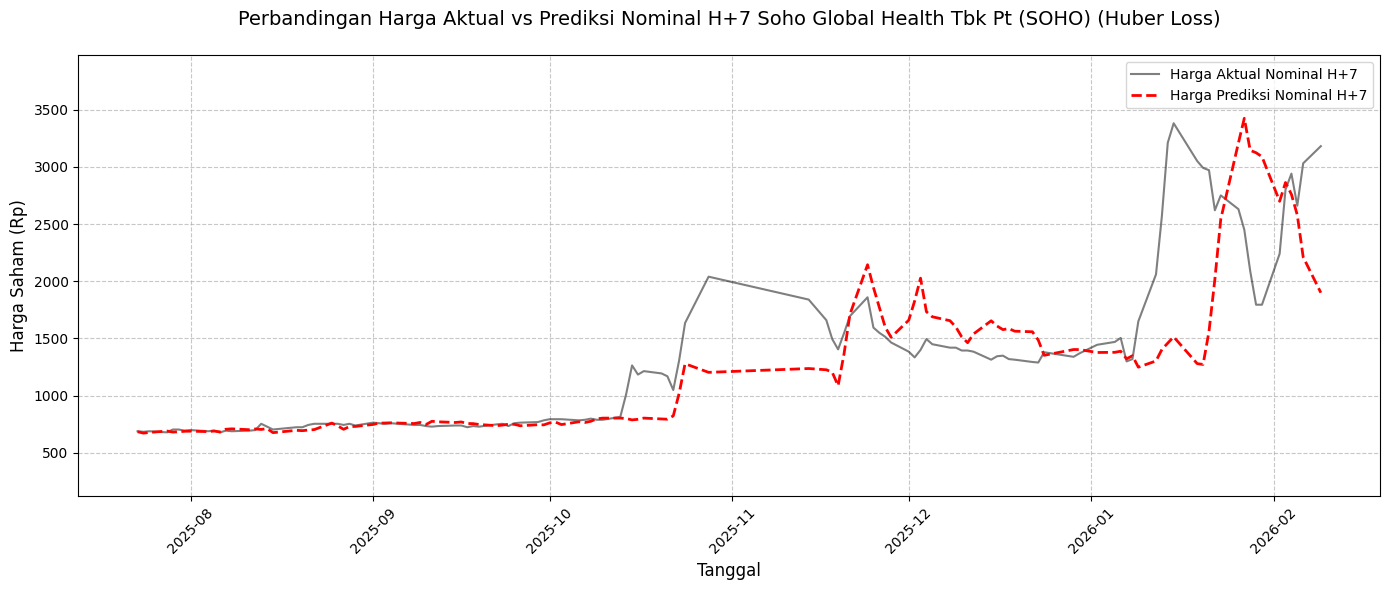

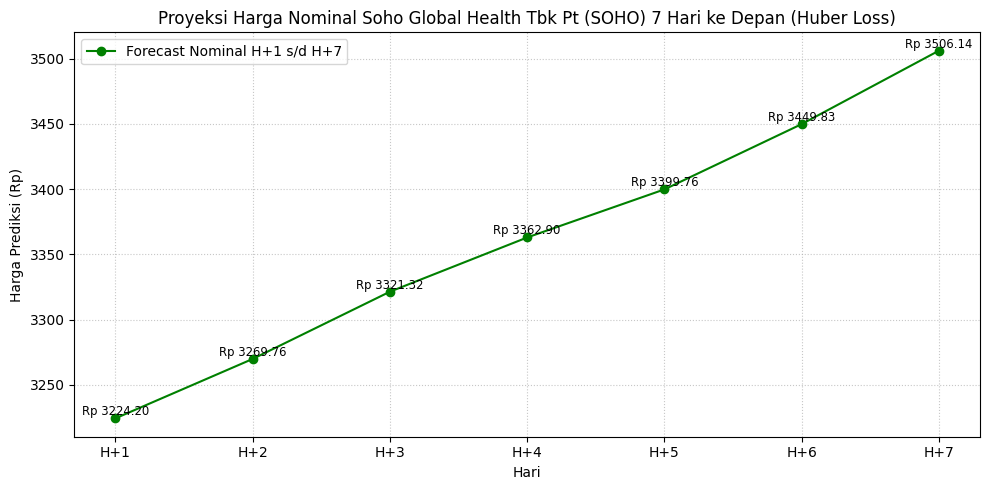


TABEL HASIL PREDIKSI NOMINAL GABUNGAN TRAIN & TEST (Soho Global Health Tbk Pt (SOHO))
  Tanggal Evaluasi Jenis Data  Aktual H+1  Prediksi H+1  Error (%) H+1  Aktual H+2  Prediksi H+2  Error (%) H+2  Aktual H+3  Prediksi H+3  Error (%) H+3  Aktual H+4  Prediksi H+4  Error (%) H+4  Aktual H+5  Prediksi H+5  Error (%) H+5  Aktual H+6  Prediksi H+6  Error (%) H+6  Aktual H+7  Prediksi H+7  Error (%) H+7
0       10-03-2023      Train       533.0    543.247864       1.922676       518.0    543.639709       4.949751       520.0    543.946594       4.605114       520.0    544.512268       4.713898       520.0    545.160706       4.838597       520.0    545.411804       4.886885       520.0    545.456787       4.895536
1       13-03-2023      Train       518.0    532.945801       2.885290       520.0    533.025024       2.504812       520.0    533.025024       2.504812       520.0    533.294800       2.556692       520.0    533.626770       2.620533       520.0    533.558533       2.607410    

In [11]:
import os  # Untuk manajemen direktori/folder
import joblib  # Untuk save atau load objek pendukung eksternal atau scaler data
import tensorflow as tf  # Framework utama untuk memproses model Deep Learning
import numpy as np  # Untuk manipulasi struktur data matriks (Array) sebagai input wajib model TensorFlow
import pandas as pd # Untuk mengolah hasil prediksi ke dalam bentuk tabel tabular
import matplotlib.pyplot as plt  # Modul plot grafik untuk visualisasi performa model
from tensorflow.keras.layers import LSTM, Dense, Input, Layer  # lapisan jaringan saraf untuk menyusun struktur model LSTM
from tensorflow.keras.models import Model  # Wadah untuk menyatukan seluruh lapisan menjadi satu model utuh
from tensorflow.keras.callbacks import EarlyStopping  # Tambahan Callback untuk menghentikan epoch jika jenuh
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Metrik statistik evaluasi

# Membuat Folder Saved Model dan Scaler
BASE_DIR = "saved_model"
MODEL_DIR = os.path.join(BASE_DIR, "model")
SCALER_DIR = os.path.join(BASE_DIR, "scaler")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(SCALER_DIR, exist_ok=True)


# Fungsi internal Balikin hasil prediksi scaler ke angka asli Log Return
def inverse_transform_target(y_pred, scaler_obj):
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)

    n_days = y_pred.shape[1]
    result = []

    for i in range(n_days):
        col_data = y_pred[:, i].reshape(-1, 1)
        inv = scaler_obj.inverse_transform(col_data)[:, 0]
        result.append(inv)

    return np.array(result).T


# === FUNGSI KONVERSI LOG RETURN -> SIMPLE RETURN -> HARGA NOMINAL ===
def log_return_to_nominal(y_scaled, scaler_obj, p_base_array):
    # 1. Inverse transform ke skala Log Return asli
    y_log = inverse_transform_target(y_scaled, scaler_obj)
    
    # 2. Hitung Simple Return: R_simple = exp(R_log) - 1
    y_simple = np.exp(y_log) - 1
    
    # 3. Rekonstruksi Harga Nominal secara kumulatif sekuensial (H+1 s/d H+7)
    y_nominal = np.zeros_like(y_log)
    for i in range(len(p_base_array)):
        current_price = p_base_array[i]  # Harga dasar (hari terakhir di window lookback)
        for h in range(7):
            # Harga_t = Harga_{t-1} * (1 + Simple_Return)
            current_price = current_price * (1 + y_simple[i, h])
            y_nominal[i, h] = current_price
            
    return y_nominal


# Attention Mechanism Layer
@tf.keras.utils.register_keras_serializable()
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
        
    def build(self, input_shape):
        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="normal"
        )
        self.b = self.add_weight(
            name="att_bias",
            shape=(input_shape[1], 1),
            initializer="zeros"
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(
            tf.keras.backend.dot(x, self.W) + self.b
        )
        a = tf.keras.backend.softmax(
            e,
            axis=1
        )
        output = tf.keras.backend.sum(
            x * a,
            axis=1
        )
        return output

    def get_config(self):
        config = super().get_config()
        return config


# Membuat Model
def create_model(input_shape, units, layers, lr):
    inputs = Input(shape=input_shape)
    x = inputs

    for _ in range(layers):
        x = LSTM(
            units,
            return_sequences=True
        )(x)

    x = AttentionLayer()(x)
    outputs = Dense(7)(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=lr
        ),
        loss="huber",  # PERUBAHAN: Mengubah "mse" menjadi "huber" agar lebih mengikuti volatilitas tajam
        metrics=["mae"]
    )
    return model


# =====================================================================
# KONFIGURASI PARAMETER
# =====================================================================
stock = "Soho Global Health Tbk Pt (SOHO)"

cfg = {
    "hidden": 32,      
    "layers": 1,       
    "lr": 0.001,       
    "win": 30          # Windowing lookback tetap 30 hari
}

# Ambil data scaled (Berisi data Log Return dari preprocessing)
data_scaled = processed_dfs[stock]["scaled"]

if data_scaled.ndim == 1:
    data_scaled = data_scaled.reshape(-1, 1)

scaler_obj = processed_dfs[stock]["scaler"]
win = cfg["win"]

# Ambil array harga nominal asli untuk menjadi jangkar (P_base) saat denormalisasi nominal
prices_nominal = processed_dfs[stock]["df"]["Terakhir"].values

X_u = []
y_u = []
P_base_u = []  # Menyimpan harga nominal hari terakhir di setiap jendela lookback

for i in range(len(data_scaled) - win - 7 + 1):
    X_u.append(data_scaled[i:i+win])  
    y_u.append(data_scaled[i+win:i+win+7, 0])  
    # Jangkar harga nominal berada pada hari terakhir dari window input (indeks: i + win - 1)
    P_base_u.append(prices_nominal[i + win - 1])

X_u = np.array(X_u)
y_u = np.array(y_u)
P_base_u = np.array(P_base_u)

# === DATA SPLITTING ===
total_len = len(processed_dfs[stock]["df"])
split_idx = int(0.8 * total_len)
split = split_idx - win

X_train = X_u[:split]
X_test = X_u[split:]

y_train = y_u[:split]
y_test = y_u[split:]

# Memisahkan jangkar harga nominal ke data train & test
P_base_train = P_base_u[:split]
P_base_test = P_base_u[split:]

print("\n===================================")
print("DATA SPLIT (UNIVARIATE LOG RETURN)")
print("===================================")
print("Train :", X_train.shape)
print("Test  :", X_test.shape)

df_dates = processed_dfs[stock]["df"]["Tanggal"].reset_index(drop=True)

train_start_date = df_dates.iloc[0]
train_end_date = df_dates.iloc[split_idx - 1]

test_start_date = df_dates.iloc[split_idx]
test_end_date = df_dates.iloc[-1]

print("\n===================================")
print("RENTANG TANGGAL DATASET")
print("===================================")
print(f"Data Latih (Train) : {train_start_date.strftime('%d %B %Y')} s/d {train_end_date.strftime('%d %B %Y')}")
print(f"Data Uji (Test)    : {test_start_date.strftime('%d %B %Y')} s/d {test_end_date.strftime('%d %B %Y')}")

# Melatih model
model_u = create_model(
    input_shape=(win, 1),
    units=cfg["hidden"],
    layers=cfg["layers"],
    lr=cfg["lr"]
)

print("\n===================================")
print(f"SUMMARY MODEL {stock}")
print("===================================")
model_u.summary()

# Menambahkan callback Early Stopping untuk memantau data validasi
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True, 
    verbose=1
)

# Memulai Proses Training
print(f"\nTraining model {stock} dengan Huber Loss...")
history = model_u.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,                 # Menggunakan 50 epoch sesuai instruksi sebelumnya
    batch_size=32,
    shuffle=False,
    callbacks=[early_stop], 
    verbose=1
)

# Simpan Model & Scaler
model_path = os.path.join(MODEL_DIR, f"{stock}_lstm_attention_huber.keras")
model_u.save(model_path)

scaler_path = os.path.join(SCALER_DIR, f"{stock}_scaler_huber.pkl")
joblib.dump(scaler_obj, scaler_path)

# Membuat Prediksi mentah (skala Log Return ternormalisasi)
preds = model_u.predict(X_test, verbose=0)
preds_train = model_u.predict(X_train, verbose=0)

# === PROSES UTAMA: KONVERSI HASIL KE HARGA NOMINAL RUPIAH ===
y_test_inv = log_return_to_nominal(y_test, scaler_obj, P_base_test)
preds_inv = log_return_to_nominal(preds, scaler_obj, P_base_test)

y_train_inv = log_return_to_nominal(y_train, scaler_obj, P_base_train)
preds_train_inv = log_return_to_nominal(preds_train, scaler_obj, P_base_train)


# === REVISI EVALUASI BERDASARKAN HARGA NOMINAL ===
print("\n=========================================================================")
print("HASIL EVALUASI MODEL DALAM SKALA HARGA NOMINAL RUPIAH (H+1 s/d H+7)")
print("=========================================================================")
print(f"{'Horizon':<10}{'MAE (Test)':<15}{'RMSE (Test)':<15}{'MAPE (Test)':<15}{'R2 (Train)':<15}")
print("-" * 72)

for h in range(7):
    y_true_step = y_test_inv[:, h]
    y_pred_step = preds_inv[:, h]
    y_true_safe = np.where(y_true_step == 0, 1e-8, y_true_step)
    
    mae_step = mean_absolute_error(y_true_step, y_pred_step)
    rmse_step = np.sqrt(mean_squared_error(y_true_step, y_pred_step))
    mape_step = np.mean(np.abs((y_true_step - y_pred_step) / y_true_safe)) * 100
    
    y_true_train_step = y_train_inv[:, h]
    y_pred_train_step = preds_train_inv[:, h]
    r2_step = r2_score(y_true_train_step, y_pred_train_step)
    
    print(f"H+{h+1:<8}{mae_step:<15.2f}{rmse_step:<15.2f}{mape_step:<14.2f}%{r2_step:<15.4f}")


# Prediksi Masa Depan (H+1 s/d H+7) dari baris paling terakhir data
last_window = data_scaled[-win:].reshape(1, win, 1)
future_pred = model_u.predict(last_window, verbose=0)

# Jangkar untuk masa depan adalah harga penutupan paling terakhir di dataset asli
last_nominal_price = processed_dfs[stock]["df"]["Terakhir"].iloc[-1]
future_prices = log_return_to_nominal(future_pred, scaler_obj, [last_nominal_price]).flatten()

print("\n===================================")
print("HASIL PREDIKSI MASA DEPAN NOMINAL (H+1 s/d H+7)")
print("===================================")
for h in range(7):
    print(f"Prediksi Harga H+{h+1} : Rp {future_prices[h]:.2f}")

# === PLOT GRAFIK HARGA NOMINAL H+7 ===
plt.figure(figsize=(14, 6))
test_dates_h7 = df_dates.iloc[split_idx + 6 : split_idx + 6 + len(preds_inv)].reset_index(drop=True)

plt.plot(test_dates_h7.values, y_test_inv[:, 6], label='Harga Aktual Nominal H+7', color='black', alpha=0.5, linewidth=1.5)
plt.plot(test_dates_h7.values, preds_inv[:, 6], label='Harga Prediksi Nominal H+7', color='red', linestyle='--', linewidth=2)

plt.title(f'Perbandingan Harga Aktual vs Prediksi Nominal H+7 {stock} (Huber Loss)\n', fontsize=14)
plt.xlabel('Tanggal', fontsize=12) 
plt.ylabel('Harga Saham (Rp)', fontsize=12)

y_min = min(np.min(y_test_inv[:, 6]), np.min(preds_inv[:, 6]))
y_max = max(np.max(y_test_inv[:, 6]), np.max(preds_inv[:, 6]))
buffer = (y_max - y_min) * 0.2  
plt.ylim(y_min - buffer, y_max + buffer)

plt.xticks(rotation=45) 
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() 
plt.show()

# === PLOT GRAFIK FORECAST 7 HARI KE DEPAN ===
plt.figure(figsize=(10, 5))
x = np.arange(1, 8)
plt.plot(x, future_prices, marker='o', linestyle='-', color='green', label='Forecast Nominal H+1 s/d H+7')
plt.xticks(x, [f'H+{i}' for i in range(1, 8)])
plt.title(f'Proyeksi Harga Nominal {stock} 7 Hari ke Depan (Huber Loss)')
plt.xlabel('Hari')
plt.ylabel('Harga Prediksi (Rp)')

for i, price in enumerate(future_prices):
    plt.text(i + 1, price, f'Rp {price:.2f}', ha='center', va='bottom', fontsize='small')

plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# === PEMBUATAN TABEL EXCEL NOMINAL ===
window_size = win 
train_dates = df_dates.iloc[window_size : window_size + len(preds_train_inv)].reset_index(drop=True)
test_dates = df_dates.iloc[split_idx : split_idx + len(preds_inv)].reset_index(drop=True)

df_train = pd.DataFrame({
    'Tanggal Evaluasi': train_dates.dt.strftime('%d-%m-%Y'),
    'Jenis Data': 'Train'
})

for h in range(7):
    df_train[f'Aktual H+{h+1}'] = y_train_inv[:, h]
    df_train[f'Prediksi H+{h+1}'] = preds_train_inv[:, h]
    df_train[f'Error (%) H+{h+1}'] = (np.abs(y_train_inv[:, h] - preds_train_inv[:, h]) / np.where(y_train_inv[:, h] == 0, 1e-8, y_train_inv[:, h])) * 100

df_test = pd.DataFrame({
    'Tanggal Evaluasi': test_dates.dt.strftime('%d-%m-%Y'),
    'Jenis Data': 'Test'
})

for h in range(7):
    df_test[f'Aktual H+{h+1}'] = y_test_inv[:, h]
    df_test[f'Prediksi H+{h+1}'] = preds_inv[:, h]
    df_test[f'Error (%) H+{h+1}'] = (np.abs(y_test_inv[:, h] - preds_inv[:, h]) / np.where(y_test_inv[:, h] == 0, 1e-8, y_test_inv[:, h])) * 100

df_hasil_per_baris = pd.concat([df_train, df_test], ignore_index=True)

print("\n=====================================================================")
print(f"TABEL HASIL PREDIKSI NOMINAL GABUNGAN TRAIN & TEST ({stock})")
print("=====================================================================")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', 10) 
print(df_hasil_per_baris.head(10))

excel_output_path = os.path.join(BASE_DIR, "Hasil_Prediksi_SOHO_HuberLoss.xlsx")
try:
    df_hasil_per_baris.to_excel(excel_output_path, index=False)
    print(f"\nHasil lengkap nominal rupiah berhasil diekspor ke: {excel_output_path}")
except PermissionError:
    print(f"\nERROR: Gagal menyimpan ke {excel_output_path}. Pastikan file tidak sedang dibuka.")